In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [4]:
location = "edge"
N_r = 10

In [5]:
Delta_SOC = -5
t = -1
delta = 0.832

# Spin-Liquid Occupations

x1 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

x3 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

cases = {
    0: {"U": 1, "x":x1},
    1: {"U": 3, "x":x3} 
}

In [6]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = N_r,
        N_k = 200,
        location = location,
        BZ = "reduced",
        dangling_bonds=True
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [33]:
import numpy as np
edge_sites = [0, 1, 2, -3 -2, -1]
j_3_2 = [i for i in range (120, 231)] #[i for i in range (236, 471)]
threshold = 0.2
site_idx = 23

## Case 0

In [34]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

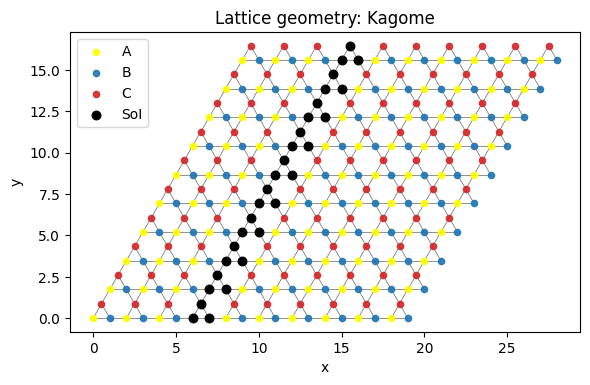

In [35]:
g.plot_lattice(
    sites_of_interest=tb_edge.sublattice_idxs
)

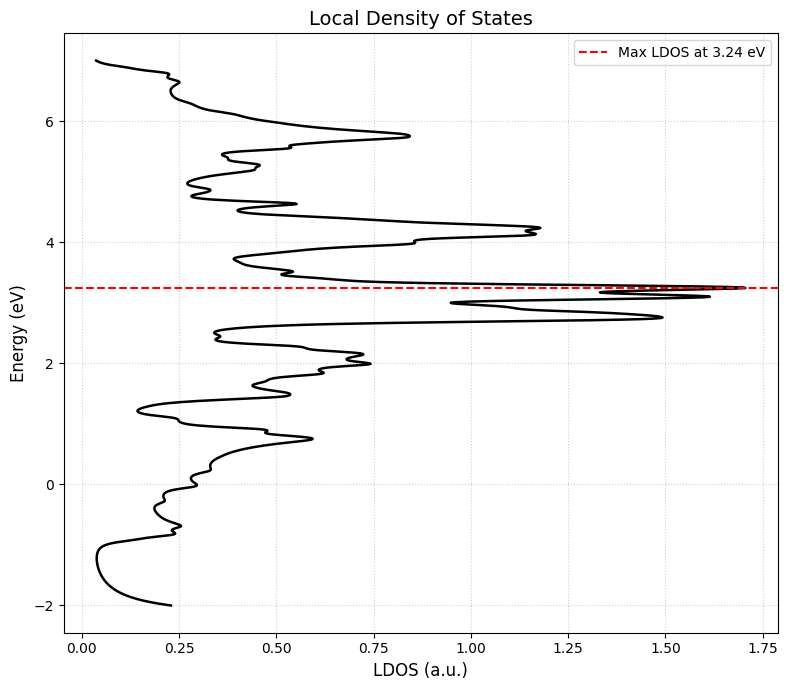

In [36]:
LDOS_23, E_23 = invariants.get_local_density_of_states(
    site_idx = 23,
    E_max = 7, 
    E_min = -2,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS_23, E_23)

In [37]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 7, 
    E_min = -2,
    eta = 0.05
)


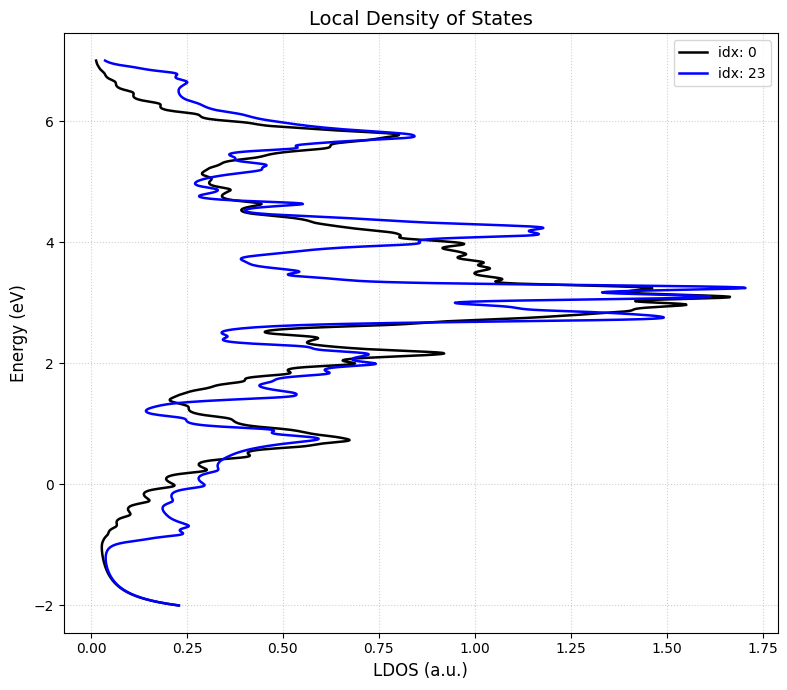

In [38]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
# idx_max = np.argmax(LDOS_0)
# E_peak = E[idx_max]
fig, ax = plt.subplots(figsize=figsize)
# ax.plot(E_vals, LDOS, color="k", lw=1.8)
ax.plot(E_0, LDOS_0, color="k", lw=1.8, label=f"idx: {0}")
ax.plot(E_23, LDOS_23, color="b", lw=1.8, label=f"idx: {23}")
# if True:
#     ax.axhline(
#         E_peak,
#         color="r",
#         linestyle='--',
#         linewidth=1.5,
#         label=f'Max {xlabel} at {E_peak:.2f} eV'
#     )
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

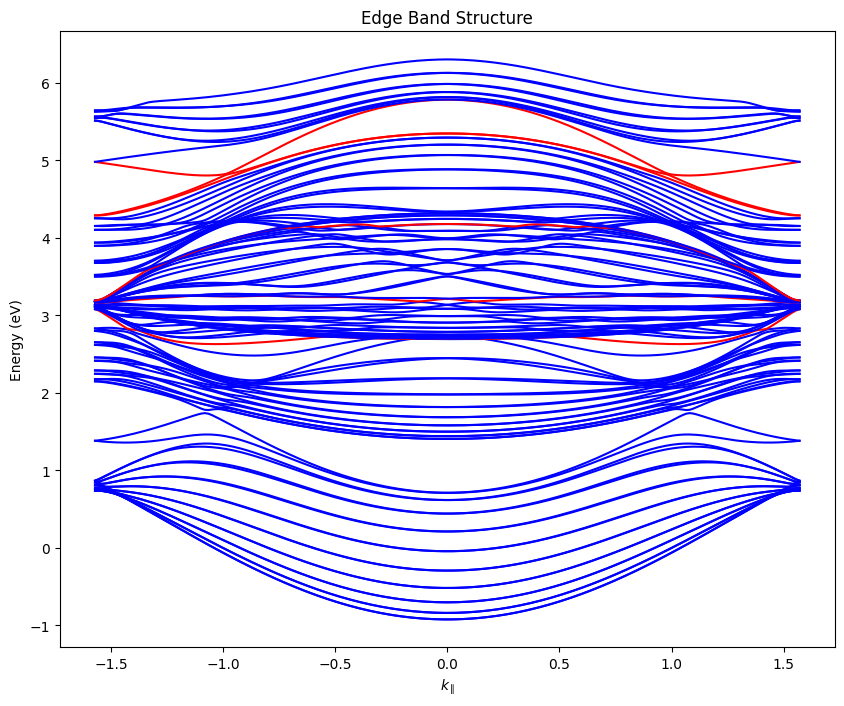

In [39]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-0.8, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.52, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=min(g.k_edge), threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

band idx: 160


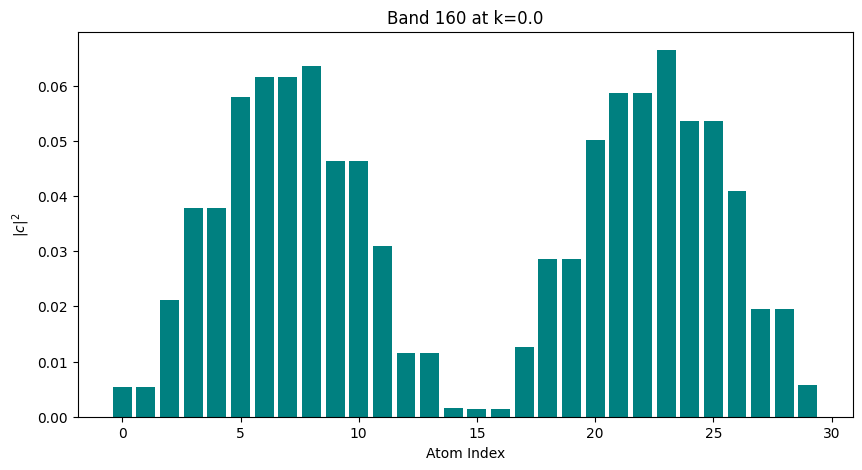

band idx: 180


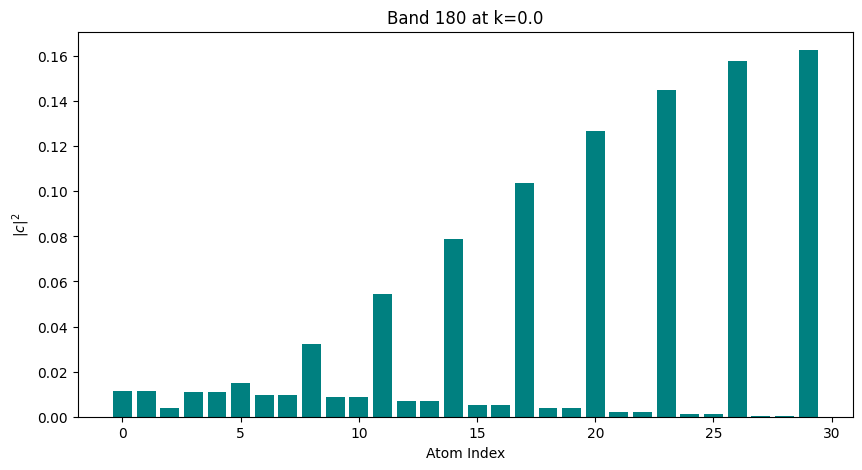

band idx: 199


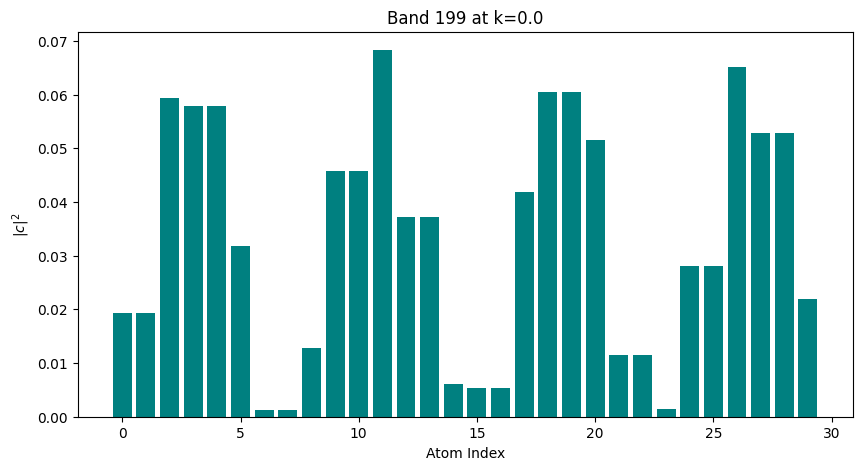

band idx: 218


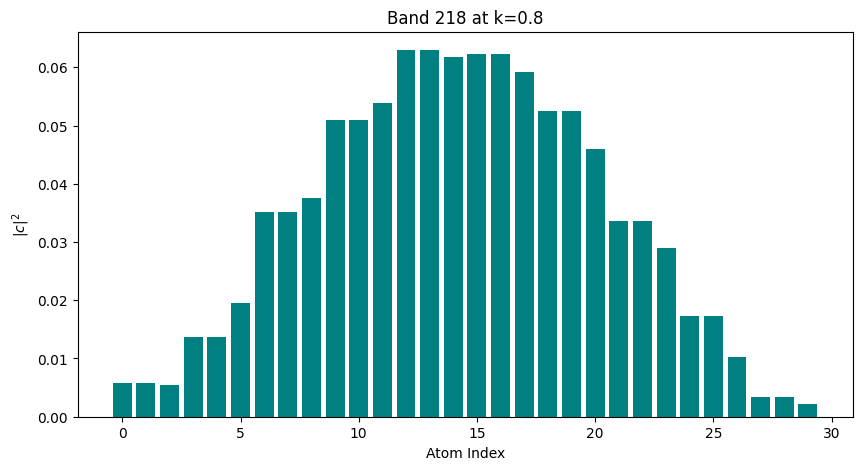

band idx: 219


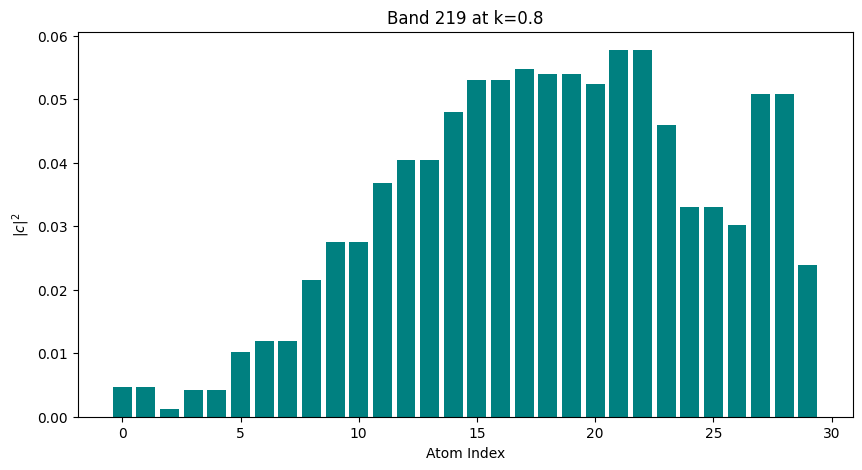

band idx: 220


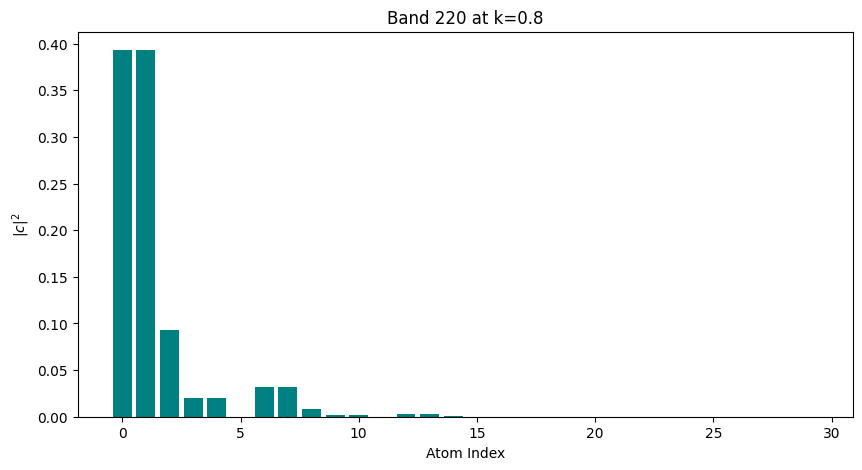

In [40]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -0.8
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()

## Case 1

In [41]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

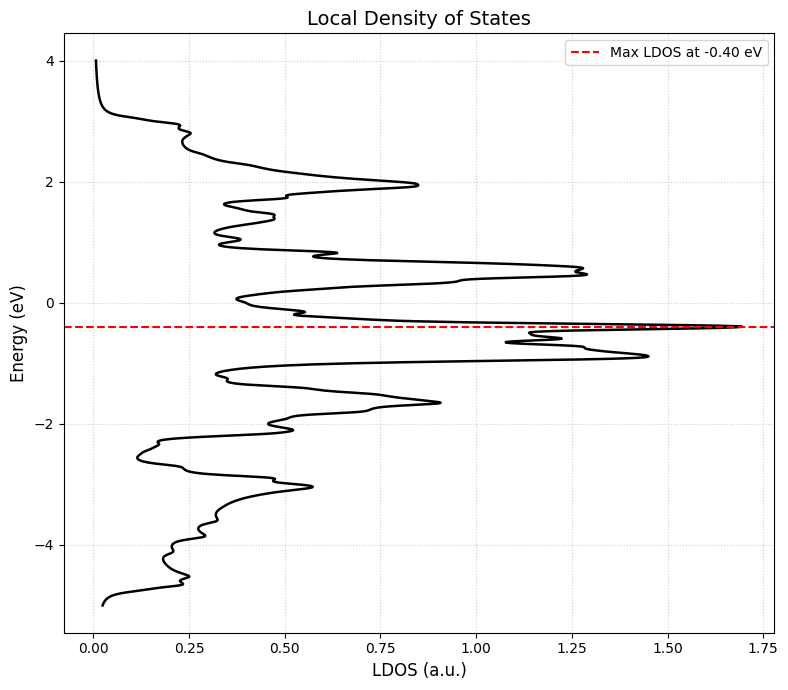

In [42]:
LDOS, E = invariants.get_local_density_of_states(
    site_idx = site_idx,
    E_max = 4, 
    E_min = -5,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS, E)

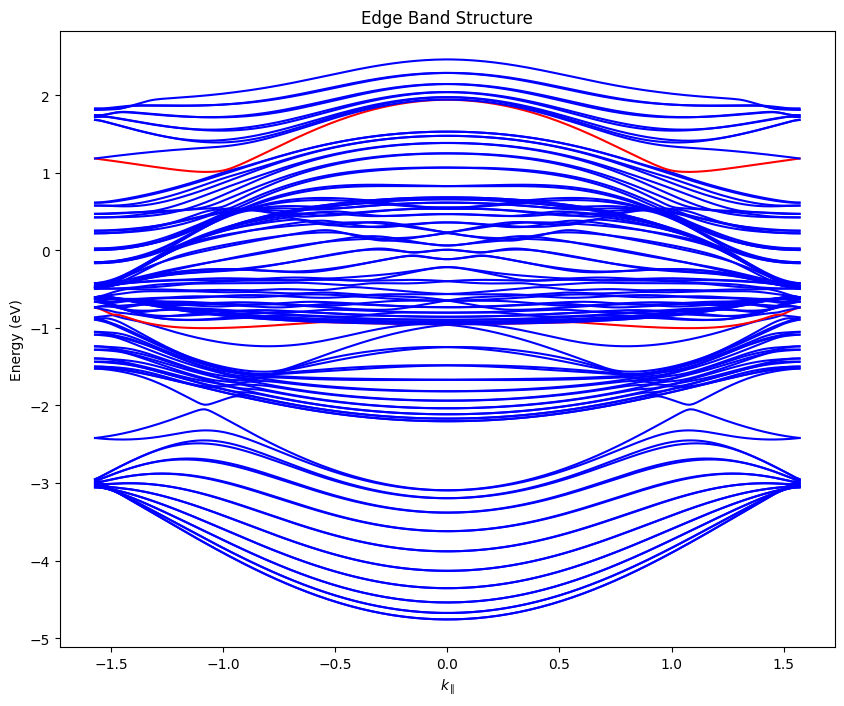

In [43]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-0.8, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.8, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

band idx: 160
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.74404695e-02+0.00000000e+00j, -8.32667268e-17-4.85722573e-17j,
       -3.88578059e-16+1.72604986e-16j,  2.05858887e-01+1.94054840e-01j,
       -1.22124533e-15-1.63354375e-16j,  2.31100854e-01+1.63063445e-01j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.74404695e-02+0.00000000e+00j, -8.32667268e-17-4.85722573e-17j,
       -3.88578059e-16+1.72604986e-16j,  2.05858887e-01+1.94054840e-01j,
       -1.22124533e-15-1.63354375e-16j,  2.31100854e-01+1.63063445e-01j]), 1: array([-9.36750677e-17-2.77555756e-17j, -5.55111512e-17-4.85722573e-17j,
        1.47960396e-02-9.23294047e-03j, -8.32667268e-17+1.78733522e-17j,
       -1.11022302e-16+2.91618329e-16j, -7.19131703e-02+2.73612240e-01j,
       -5.55111512e-17-2.63265187e-16j, -1.09734563e-01+2.60682983e-01j]), 2: array([ 2.77555756e-17-4.16333634e-17j,  1.38777878e-17-4.85722573e-17j,
       -8.7603486

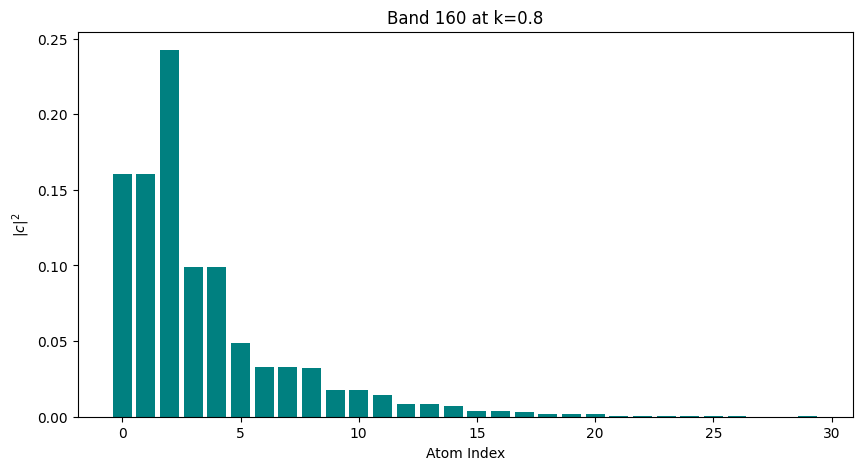

band idx: 220
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.79496237e-02+0.00000000e+00j,  5.55111512e-17+2.86229374e-17j,
        2.22044605e-16-6.52256027e-16j,  2.61315620e-01-1.39236721e-02j,
        2.77555756e-17-4.58848410e-16j, -5.35344830e-01-2.76342468e-02j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.79496237e-02+0.00000000e+00j,  5.55111512e-17+2.86229374e-17j,
        2.22044605e-16-6.52256027e-16j,  2.61315620e-01-1.39236721e-02j,
        2.77555756e-17-4.58848410e-16j, -5.35344830e-01-2.76342468e-02j]), 1: array([-1.11022302e-16-6.93889390e-18j,  1.11022302e-16-4.68375339e-17j,
       -2.75437541e-02-4.74584797e-03j,  0.00000000e+00+5.98715722e-17j,
       -2.42861287e-16-1.45008565e-16j, -2.55156693e-01-5.80928896e-02j,
       -5.27355937e-16-2.26864955e-16j,  5.32263135e-01+6.36686310e-02j]), 2: array([ 0.00000000e+00+3.12250226e-17j,  2.77555756e-17-2.77555756e-17j,
       -2.3513850

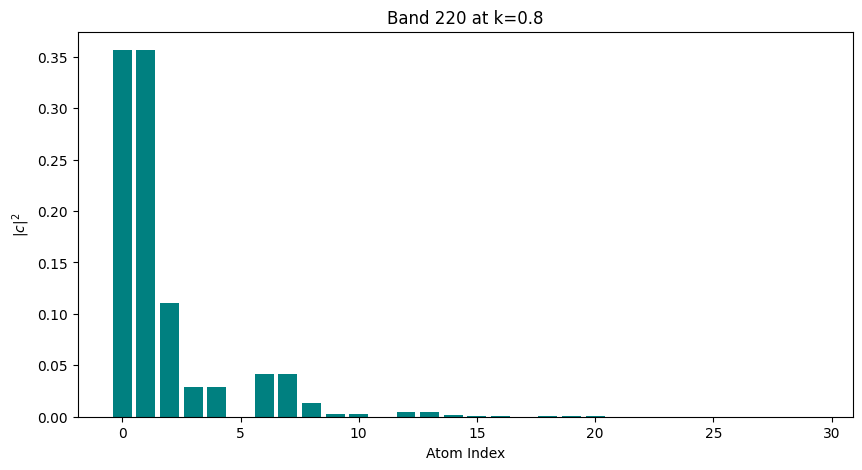

In [44]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -0.8
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 
        if i == 0 or i == 23:
            print(atomic_wavefunctions)

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()